In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1b"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)

In [2]:
val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)

# n_hidden (fixed depth=0)

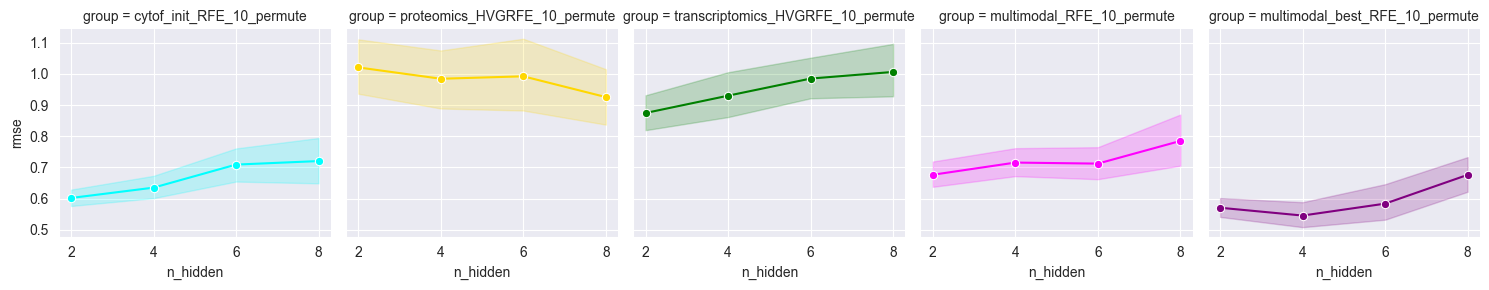

In [3]:
val_df["group"] = val_df["context"] + "_" + val_df["features"]

palette = {
    "cytof_init_RFE_10_permute": "cyan",
    "proteomics_HVGRFE_10_permute": "gold",
    "transcriptomics_HVGRFE_10_permute": "green",
    "multimodal_RFE_10_permute": "magenta",
    "multimodal_best_RFE_10_permute": "purple"
}

g = sns.FacetGrid(
    val_df[(val_df.depth == 0) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-4)],
    col="group",
    col_order=palette.keys()
)

g.map_dataframe(
    sns.lineplot,
    x="n_hidden",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [4]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric, context_metric="context"):
    for context in df[context_metric].unique():
        context_data = df[df[context_metric] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context/Group: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

In [5]:
kruskal_wallis_groups(
    val_df[(val_df.depth == 0) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-4)],
    "rmse",
    "n_hidden",
    "group"
)

Context/Group: multimodal_best_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=16.85, p-value=0.0008, significant? True
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=1.90, p-value=0.5930, significant? False
Context/Group: transcriptomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=5.13, p-value=0.1627, significant? False
Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=2.18, p-value=0.5366, significant? False
Context/Group: cytof_init_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=11.84, p-value=0.0080, significant? True


# No significant effect from `n_hidden`, if not for the worse for cytof_init and multimodal_best.

# depth (fixed n_hidden = 2)

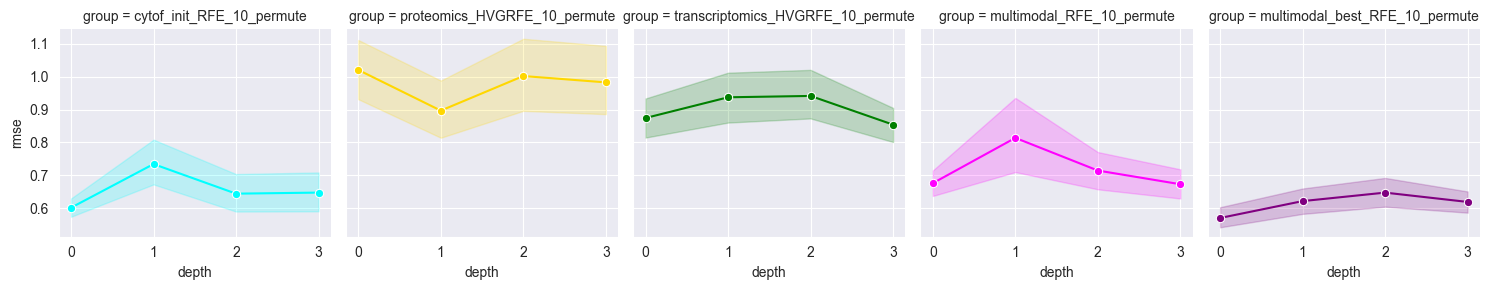

In [6]:
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-4)],
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="depth",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [7]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-4)],
    "rmse",
    "depth",
    "group"
)

Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=4.78, p-value=0.1886, significant? False
Context/Group: transcriptomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=2.72, p-value=0.4363, significant? False
Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=2.90, p-value=0.4076, significant? False
Context/Group: multimodal_best_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=7.97, p-value=0.0465, significant? True
Context/Group: cytof_init_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=8.05, p-value=0.0449, significant? True


# No significant effect from `depth`, if not for the worse for cytof_init and multimodal_best.

# `l1reg_inflater_output` (fixed `n_hidden`, `depth` and `l2reg_inflater_output`)

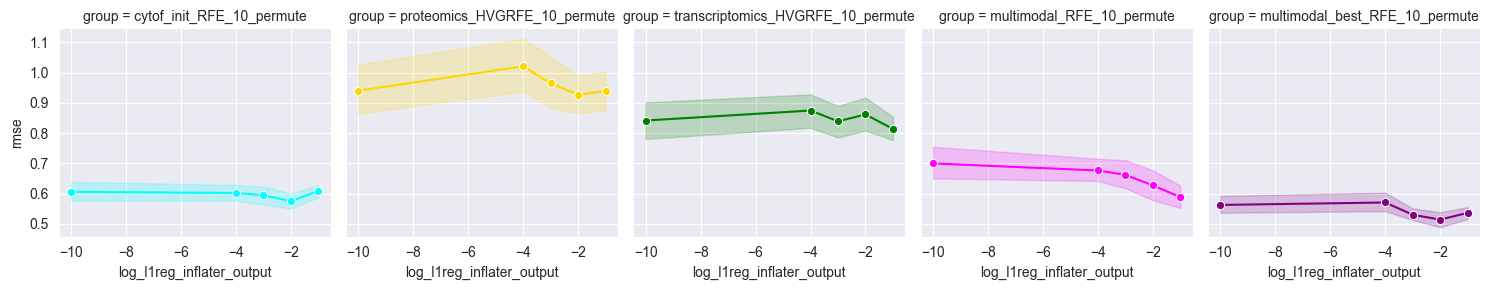

In [8]:
import numpy as np

val_df["log_l1reg_inflater_output"] = np.where(
    val_df["l1reg_inflater_output"] != 0,
    np.log10(val_df["l1reg_inflater_output"]),
    -10
)
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l2reg_inflater_output == 0)],
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_l1reg_inflater_output",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [9]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l2reg_inflater_output == 0)],
    "rmse",
    "log_l1reg_inflater_output",
    "group"
)

Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=2.66, p-value=0.6158, significant? False
Context/Group: transcriptomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=4.26, p-value=0.3725, significant? False
Context/Group: multimodal_best_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=12.41, p-value=0.0145, significant? True
Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=16.03, p-value=0.0030, significant? True
Context/Group: cytof_init_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=6.80, p-value=0.1466, significant? False


# Effect of `l1reg_inflater_output` seems to be significant for the multimodal contexts! We might want to investigate this further...but still, there is no significance in the single contexts we are most interested in...

# `l2reg_inflater_output` (fixed `n_hidden`, `depth` and `l1reg_inflater_output`)

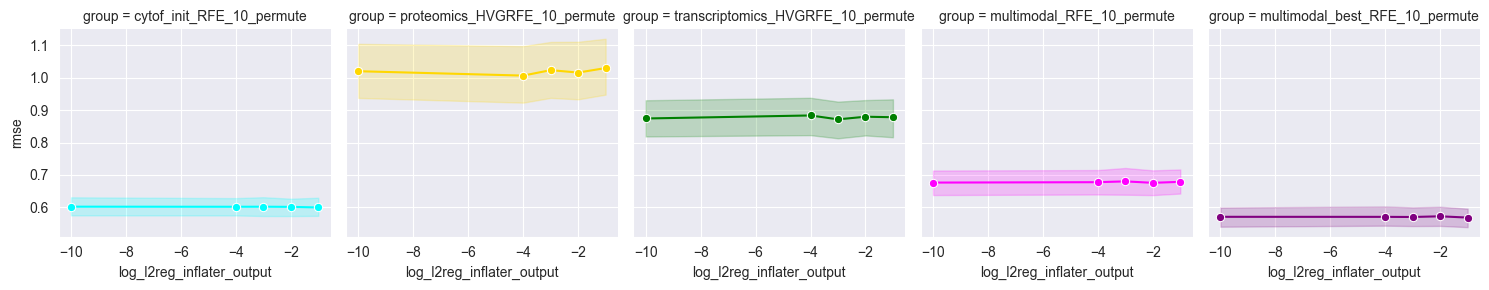

In [10]:
import numpy as np

val_df["log_l2reg_inflater_output"] = np.where(
    val_df["l2reg_inflater_output"] != 0,
    np.log10(val_df["l2reg_inflater_output"]),
    -10
)
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-4)],
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_l2reg_inflater_output",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [11]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-4)],
    "rmse",
    "log_l2reg_inflater_output",
    "group"
)

Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.34, p-value=0.9872, significant? False
Context/Group: transcriptomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.06, p-value=0.9995, significant? False
Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.01, p-value=1.0000, significant? False
Context/Group: multimodal_best_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.13, p-value=0.9979, significant? False
Context/Group: cytof_init_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.02, p-value=0.9999, significant? False


# No significant effect from `l2_reg_inflater_output` either...

# As best_RFE_10_permute outperforms RFE_10_permute for multimodal, we can subset to that feature selection strategy only and rather look at sample split

In [12]:
val_df = val_df[~((val_df["context"] == "multimodal") &
                  (val_df["features"] == "RFE_10_permute"))]

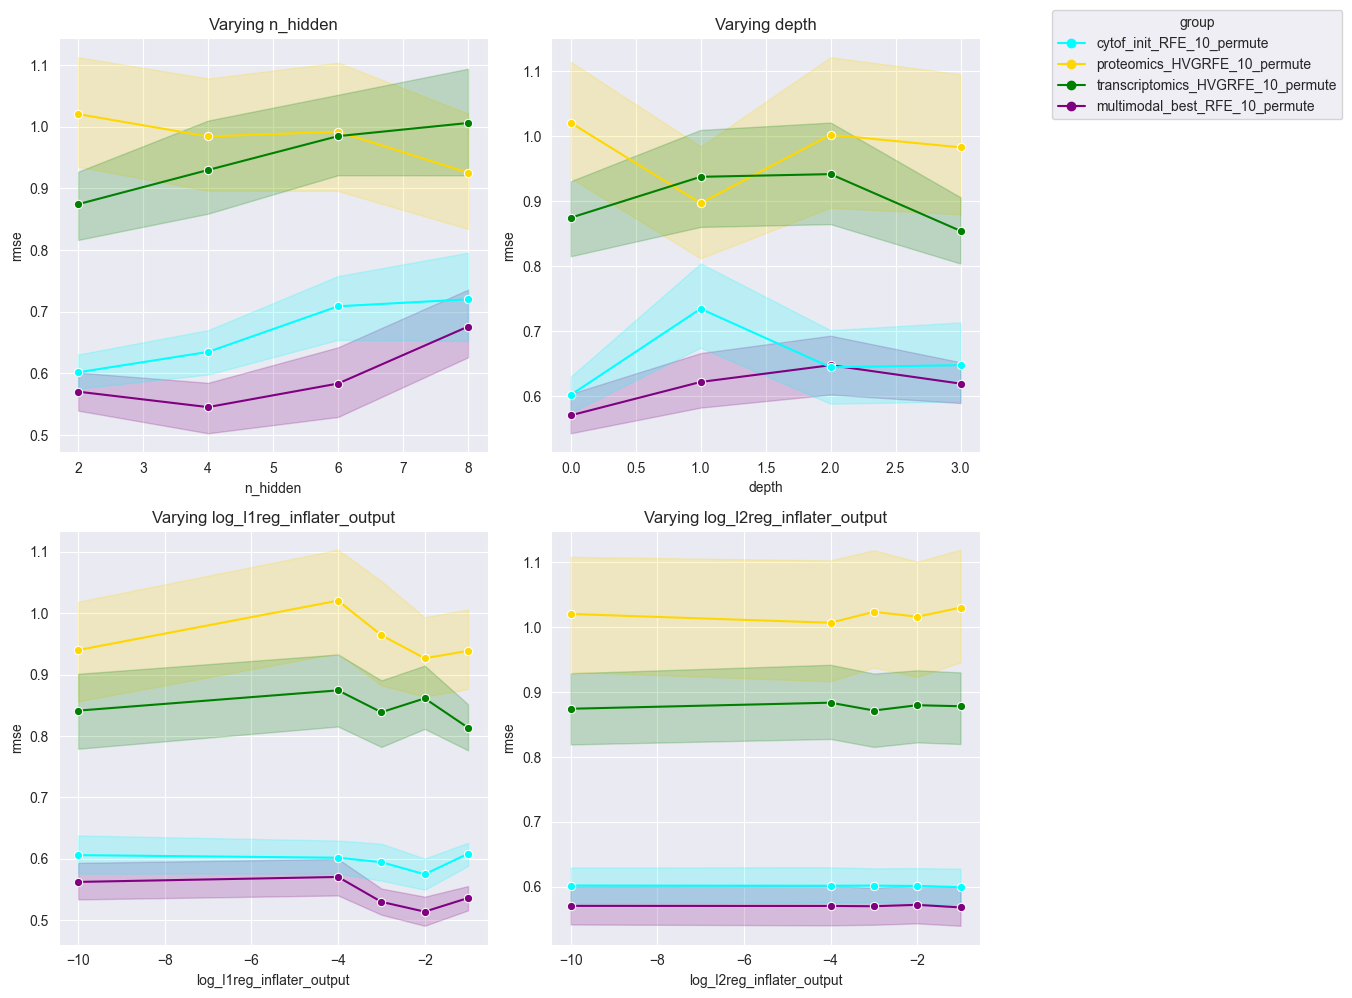

In [13]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

param_central_values = {
    "n_hidden": 2,
    "depth": 0,
    "log_l1reg_inflater_output": -4,
    "log_l2reg_inflater_output": -10,  # ~0
}

for i, param in enumerate(param_central_values.keys()):
    mask = np.ones(len(val_df), dtype=bool)
    for parameter, value in param_central_values.items():
        if parameter == param:
            continue
        mask &= val_df[parameter] == value

    ax = axes.flat[i]
    sns.lineplot(
        data=val_df[mask],
        x=param, y="rmse",
        hue="group",
        palette=palette,
        marker="o",
        legend=False,   # suppress subplot legends
        ax=ax,
    )
    ax.set_title(f"Varying {param}")

# --- build one shared legend using palette keys (keeps your order) ---
legend_labels = [group for group in list(palette.keys()) if group != "multimodal_RFE_10_permute"]
legend_handles = [Line2D([0], [0], marker='o', linestyle='-',
                         color=palette[label], label=label)
                  for label in legend_labels]

fig.legend(legend_handles, legend_labels, title="group",
           bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Add Kruskal-Wallis stat tests

In [14]:
def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

def groupwise_kw(df, xcol, ycol, groupcol):
    results = {}
    for g, sub in df.groupby(groupcol):
        groups = [ys[ycol].values for _, ys in sub.groupby(xcol)]
        if len(groups) > 1:
            stat, p = stats.kruskal(*groups)
            results[g] = p
    return results

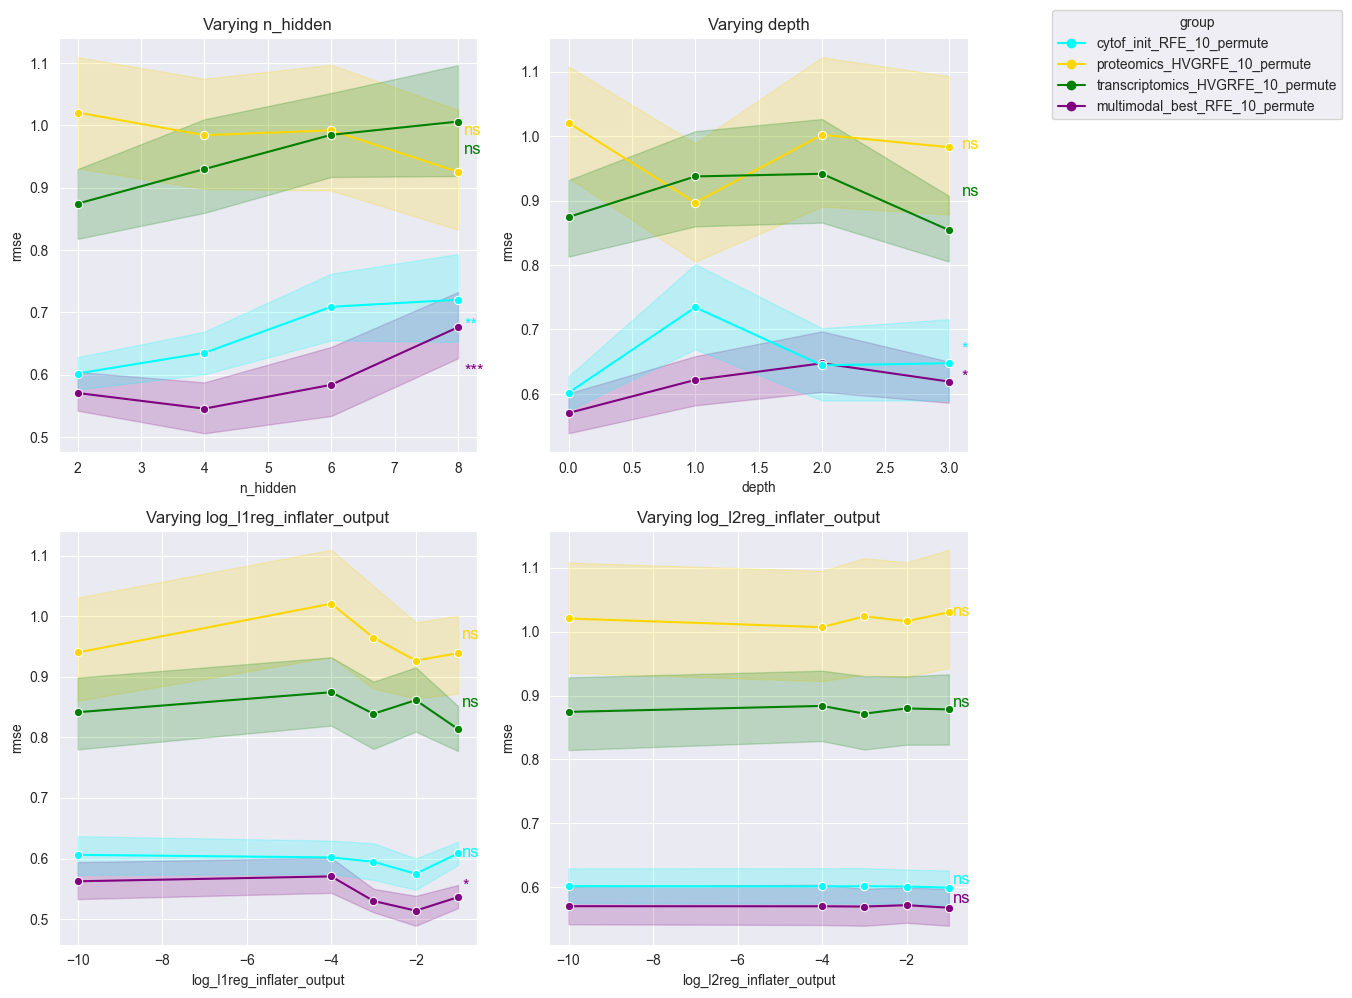

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

param_central_values = {
    "n_hidden": 2,
    "depth": 0,
    "log_l1reg_inflater_output": -4,
    "log_l2reg_inflater_output": -10,  # ~0
}

for i, param in enumerate(param_central_values.keys()):
    mask = np.ones(len(val_df), dtype=bool)
    for parameter, value in param_central_values.items():
        if parameter == param:
            continue
        mask &= val_df[parameter] == value

    ax = axes.flat[i]
    sns.lineplot(
        data=val_df[mask],
        x=param, y="rmse",
        hue="group",
        palette=palette,
        marker="o",
        legend=False,   # suppress subplot legends
        ax=ax,
    )
    ax.set_title(f"Varying {param}")

    dsub = val_df[mask]

    kw_results = groupwise_kw(dsub, xcol=param, ycol="rmse", groupcol="group")

    for g, p in kw_results.items():
        star = p_to_stars(p)
        x_pos = dsub[param].max() + 0.1
        y_pos = dsub.loc[dsub["group"] == g, "rmse"].mean()
        ax.text(
            x_pos,
            y_pos,
            star,
            color=palette[g],
            fontsize=12,
            ha="left", va="bottom"
        )

# --- build one shared legend using palette keys (keeps your order) ---
legend_labels = [group for group in list(palette.keys()) if group != "multimodal_RFE_10_permute"]
legend_handles = [Line2D([0], [0], marker='o', linestyle='-',
                         color=palette[label], label=label)
                  for label in legend_labels]

fig.legend(legend_handles, legend_labels, title="group",
           bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()